# LinkedIn Job Postings - EDA
## ***Pearsons Four - May 2026***
### Phase 1 & 2: Data Wrangling

In [ ]:
import pandas as pd
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

#### Load dataset via Kagglehub (no manual download)

In [ ]:

path = kagglehub.dataset_download("arshkon/linkedin-job-postings")
print(f"Dataset path: {path}")
print("Files available:", os.listdir(path))

Using Colab cache for faster access to the 'linkedin-job-postings' dataset.
Dataset path: /kaggle/input/linkedin-job-postings
Files available: ['companies', 'mappings', 'jobs', 'postings.csv']


##### Load main postings

In [ ]:
# Load the main postings table
df = pd.read_csv(os.path.join(path, 'postings.csv'))
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Shape: (123849, 31)
Columns: ['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips']


##### Sample for quick inspection

In [ ]:
# Take a random sample of 100k for faster exploration
df_sample = df.sample(n=100000, random_state=42)
print(f"Sample shape: {df_sample.shape}")

Sample shape: (100000, 31)


#### **Initial exploration**

In [ ]:
print("=== SHAPE ===")
print(df.shape)


=== SHAPE ===
(123849, 31)


In [ ]:
print("\n=== DTYPES ===")
print(df.dtypes)



=== DTYPES ===
job_id                          int64
company_name                   object
title                          object
description                    object
max_salary                    float64
pay_period                     object
location                       object
company_id                    float64
views                         float64
med_salary                    float64
min_salary                    float64
formatted_work_type            object
applies                       float64
original_listed_time          float64
remote_allowed                float64
job_posting_url                object
application_url                object
application_type               object
expiry                        float64
closed_time                   float64
formatted_experience_level     object
skills_desc                    object
listed_time                   float64
posting_domain                 object
sponsored                       int64
work_type                      obj

In [ ]:
print("\n=== INFO ===")
df.info()



=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  object 
 2   title                       123849 non-null  object 
 3   description                 123842 non-null  object 
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   object 
 6   location                    123849 non-null  object 
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  object 
 12  applies                     23320 non-null   float64
 13  

In [ ]:
print("\n=== DESCRIPTIVE STATISTICS ===")
df.describe()



=== DESCRIPTIVE STATISTICS ===


,job_id,max_salary,company_id,views,med_salary,min_salary,applies,original_listed_time,remote_allowed,expiry,closed_time,listed_time,sponsored,normalized_salary,zip_code,fips
count,1.238490e+05,2.979300e+04,1.221320e+05,122160.000000,6280.000000,2.979300e+04,23320.000000,1.238490e+05,15246.0,1.238490e+05,1.073000e+03,1.238490e+05,123849.0,3.607300e+04,102977.000000,96434.000000
mean,3.896402e+09,9.193942e+04,1.220401e+07,14.618247,22015.619876,6.491085e+04,10.591981,1.713152e+12,1.0,1.716213e+12,1.712928e+12,1.713204e+12,0.0,2.053270e+05,50400.491887,28713.879887
std,8.404355e+07,7.011101e+05,2.554143e+07,85.903598,52255.873846,4.959738e+05,29.047395,4.848209e+08,0.0,2.321394e+09,3.622893e+08,3.989122e+08,0.0,5.097627e+06,30252.232515,16015.929825
min,9.217160e+05,1.000000e+00,1.009000e+03,1.000000,0.000000,1.000000e+00,1.000000,1.701811e+12,1.0,1.712903e+12,1.712346e+12,1.711317e+12,0.0,0.000000e+00,1001.000000,1003.000000
25%,3.894587e+09,4.828000e+01,1.435200e+04,3.000000,18.940000,3.700000e+01,1.000000,1.712863e+12,1.0,1.715481e+12,1.712670e+12,1.712886e+12,0.0,5.200000e+04,24112.000000,13121.000000
50%,3.901998e+09,8.000000e+04,2.269650e+05,4.000000,25.500000,6.000000e+04,3.000000,1.713395e+12,1.0,1.716042e+12,1.712670e+12,1.713408e+12,0.0,8.150000e+04,48059.000000,29183.000000
75%,3.904707e+09,1.400000e+05,8.047188e+06,8.000000,2510.500000,1.000000e+05,8.000000,1.713478e+12,1.0,1.716088e+12,1.713283e+12,1.713484e+12,0.0,1.250000e+05,78201.000000,42077.000000
max,3.906267e+09,1.200000e+08,1.034730e+08,9975.000000,750000.000000,8.500000e+07,967.000000,1.713573e+12,1.0,1.729125e+12,1.713562e+12,1.713573e+12,0.0,5.356000e+08,99901.000000,56045.000000


In [ ]:
print("\n=== HEAD (5 rows) ===")
df.head()


=== HEAD (5 rows) ===


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


#### Null analysis

In [ ]:
null_pct = (df.isnull().sum() / len(df) * 100).round(2).sort_values(ascending=False)
print("=== NULL PERCENTAGE BY COLUMN ===")
print(null_pct[null_pct > 0])


=== NULL PERCENTAGE BY COLUMN ===
closed_time                   99.13
skills_desc                   98.03
med_salary                    94.93
remote_allowed                87.69
applies                       81.17
min_salary                    75.94
max_salary                    75.94
currency                      70.87
compensation_type             70.87
pay_period                    70.87
normalized_salary             70.87
posting_domain                32.27
application_url               29.60
formatted_experience_level    23.75
fips                          22.14
zip_code                      16.85
company_name                   1.39
company_id                     1.39
views                          1.36
description                    0.01
dtype: float64


In [ ]:
print("\n=== TOTAL NULL COUNT ===")
print(df.isnull().sum().sum())



=== TOTAL NULL COUNT ===
1269564


In [ ]:
print("\n=== DUPLICATES ===")
print(f"Duplicated rows: {df.duplicated().sum()}")


=== DUPLICATES ===
Duplicated rows: 0


 Interpret nulls

### Null Value Analysis
- **closed_time:** 99.13% null — expected, most jobs are still open
- **skills_desc:** 98.03% null — unstructured text, rarely filled
- **med_salary:** 94.93% null — salary data is sparse in main table
- **normalized_salary:** 70.87% null
- **formatted_experience_level:** 23.75% null
- **title:** 0% null — fully populated
- **location:** 0% null — fully populated
**Total nulls in dataset:** 1,269,564 across all columns.
**Decision:** For salary analysis, use `normalized_salary` (29% populated) which is better than `med_salary` (5%).
For skills, use the `job_skills` table instead of `skills_desc`.

#### Key categorical values

In [ ]:
cols_to_check = ['formatted_experience_level', 'formatted_work_type', 'work_type', 'application_type', 'pay_period', 'currency']
for col in cols_to_check:
    if col in df.columns:
        print(f"\n=== {col} ===")
        print(df[col].value_counts(dropna=False).head(10))


=== formatted_experience_level ===
formatted_experience_level
Mid-Senior level    41489
Entry level         36708
NaN                 29409
Associate            9826
Director             3746
Internship           1449
Executive            1222
Name: count, dtype: int64

=== formatted_work_type ===
formatted_work_type
Full-time     98814
Contract      12117
Part-time      9696
Temporary      1190
Internship      983
Volunteer       562
Other           487
Name: count, dtype: int64

=== work_type ===
work_type
FULL_TIME     98814
CONTRACT      12117
PART_TIME      9696
TEMPORARY      1190
INTERNSHIP      983
VOLUNTEER       562
OTHER           487
Name: count, dtype: int64

=== application_type ===
application_type
OffsiteApply          84607
ComplexOnsiteApply    31049
SimpleOnsiteApply      8192
UnknownApply              1
Name: count, dtype: int64

=== pay_period ===
pay_period
NaN         87776
YEARLY      20628
HOURLY      14741
MONTHLY       518
WEEKLY        177
BIWEEKLY        9

#### Location analysis

In [ ]:
# Quick location analysis
print("=== TOP 15 LOCATIONS ===")
print(df['location'].value_counts().head(15))
print("\n=== SPAIN-RELATED LOCATIONS ===")
spain = df[df['location'].str.contains('spain|españa|madrid|barcelona', case=False, na=False)]
print(f"Spain-related postings: {len(spain)}")
if len(spain) > 0:
    print(spain['location'].value_counts())

=== TOP 15 LOCATIONS ===
location
United States                      8125
New York, NY                       2756
Chicago, IL                        1834
Houston, TX                        1762
Dallas, TX                         1383
Atlanta, GA                        1363
Boston, MA                         1176
Austin, TX                         1083
Charlotte, NC                      1075
Phoenix, AZ                        1059
Washington, DC                      985
Los Angeles, CA                     972
San Francisco, CA                   884
New York City Metropolitan Area     837
Seattle, WA                         818
Name: count, dtype: int64

=== SPAIN-RELATED LOCATIONS ===
Spain-related postings: 1
location
Madrid, NY    1
Name: count, dtype: int64


#### Filter for data roles

In [ ]:
# Filter for data-related job titles
data_keywords = 'data scientist|data engineer|data analyst|machine learning|ml engineer|ai engineer|business intelligence|data architect|analytics|data manager'
df_data = df[df['title'].str.contains(data_keywords, case=False, na=False)].copy()
print(f"Data role postings found: {len(df_data)} ({len(df_data)/len(df)*100:.1f}%)")
print("\n=== TOP 20 DATA TITLES ===")
print(df_data['title'].value_counts().head(20))

Data role postings found: 1831 (1.5%)

=== TOP 20 DATA TITLES ===
title
Data Analyst                                 137
Data Engineer                                 90
Data Scientist                                56
Senior Data Engineer                          44
Data Architect                                27
Senior Data Analyst                           25
Machine Learning Engineer                     23
Senior Data Scientist                         21
Online Data Analyst                           20
Senior Machine Learning Engineer              19
Business Intelligence Developer               14
Senior Data Architect                         13
Business Intelligence Analyst                 13
Lead Data Engineer                            12
Lead Data Scientist                           11
Business Data Analyst                         10
Data Engineer II                               7
Data Scientist Lead – Telematics (Remote)      6
Business Intelligence Engineer                

### Data Roles Filtering
- Found **XX** data-related postings out of 123,849 total (XX%)
- Most common titles: data scientist, data engineer, data analyst
- These XXK rows will be the focus of our analysis

#### Keep relevant columns

In [ ]:
df_clean = df_data.copy()
print(f"Shape: {df_clean.shape}")
print(f"Columns: {list(df_clean.columns)}")

Shape: (1831, 31)
Columns: ['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips']


#### Text normalization

In [ ]:
df_clean['title'] = df_clean['title'].str.lower().str.strip()
df_clean['location'] = df_clean['location'].str.lower().str.strip()
df_clean['company_name'] = df_clean['company_name'].str.lower().str.strip()
# Extract city
df_clean['city'] = df_clean['location'].str.split(',').str[0].str.strip()
print("Text normalization complete ✅")
df_clean[['title', 'city', 'company_name']].head(10)

Text normalization complete ✅


,title,city,company_name
86,intern- business analytics,greensboro--winston-salem--high point area,lt apparel group
116,data architect,san francisco,saxon ai
165,enterprise data & analytics infrastructure man...,cleveland,keybank
283,sr data engineer with kafka,austin,zenithminds inc
360,cloud platform/ big data engineer,michigan,"subaru research and development, inc"
367,data engineer/etl,hartford,silverspace technologies inc
389,data analyst,queens,tenazx inc
483,senior data engineer/analyst - full time,california,NaN
520,senior machine learning research engineer,san francisco bay area,symbolica ai
663,machine learning engineer,dallas,nlb services


#### Experience level mapping

In [ ]:
exp_map = {
    'internship': 0,
    'entry level': 1,
    'associate': 2,
    'mid-senior level': 3,
    'director': 4,
    'executive': 5
}
df_clean['experience_level_num'] = df_clean['formatted_experience_level'].str.lower().map(exp_map)
print("=== EXPERIENCE LEVEL DISTRIBUTION ===")
print(df_clean['formatted_experience_level'].value_counts(dropna=False))

=== EXPERIENCE LEVEL DISTRIBUTION ===
formatted_experience_level
Mid-Senior level    829
NaN                 495
Entry level         279
Associate           116
Director             75
Internship           25
Executive            12
Name: count, dtype: int64


### Data Roles Filtering
- Found **1,831** data-related postings out of 123,849 total (1.5%)
- Most common titles: Data Analyst (137), Data Engineer (90), Data Scientist (56)
- **Limitation:** Dataset is US-centric. 0 postings from Spain.
- This affects the analysis for DataTalent (Spanish market). Will be documented as bias.

#### Normalized salary stats

In [ ]:
sal = df_clean['normalized_salary'].dropna()
print(f"Records with salary: {len(sal)} ({len(sal)/len(df_clean)*100:.1f}%)")
print(f"Mean: ${sal.mean():,.0f}")
print(f"Median: ${sal.median():,.0f}")
print(f"Std: ${sal.std():,.0f}")
print(f"Min: ${sal.min():,.0f}")
print(f"Max: ${sal.max():,.0f}")
print(f"\nPercentiles:")
print(sal.quantile([0.1, 0.25, 0.5, 0.75, 0.9]).round(0))

Records with salary: 621 (33.9%)
Mean: $152,897
Median: $136,275
Std: $276,456
Min: $45
Max: $6,900,400

Percentiles:
0.10     85000.0
0.25    106226.0
0.50    136275.0
0.75    170000.0
0.90    208000.0
Name: normalized_salary, dtype: float64


#### Salary outliers

In [ ]:
sal = df_clean['normalized_salary'].dropna()
print(f"Records with salary: {len(sal)} ({len(sal)/len(df_clean)*100:.1f}%)")
print(f"Mean: ${sal.mean():,.0f}")
print(f"Median: ${sal.median():,.0f}")
print(f"Std: ${sal.std():,.0f}")
print(f"Min: ${sal.min():,.0f}")
print(f"Max: ${sal.max():,.0f}")
print(f"\nPercentiles:")
print(sal.quantile([0.1, 0.25, 0.5, 0.75, 0.9]).round(0))

Records with salary: 621 (33.9%)
Mean: $152,897
Median: $136,275
Std: $276,456
Min: $45
Max: $6,900,400

Percentiles:
0.10     85000.0
0.25    106226.0
0.50    136275.0
0.75    170000.0
0.90    208000.0
Name: normalized_salary, dtype: float64


#### Merge with job_skills

In [ ]:
job_skills = pd.read_csv(os.path.join(path, 'jobs', 'job_skills.csv'))
skills_map = pd.read_csv(os.path.join(path, 'mappings', 'skills.csv'))
df_skills = df_clean.merge(job_skills, on='job_id', how='left')
df_skills = df_skills.merge(skills_map, on='skill_abr', how='left')
print("=== TOP SKILLS IN DATA ROLES ===")
top_skills = df_skills['skill_name'].value_counts().head(15)
print(top_skills)

=== TOP SKILLS IN DATA ROLES ===
skill_name
Information Technology    1274
Engineering                522
Analyst                    337
Research                   175
Other                      100
Sales                       80
Business Development        71
Finance                     48
Consulting                  48
Marketing                   38
Management                  35
Strategy/Planning           28
Human Resources             22
Product Management          22
Administrative              18
Name: count, dtype: int64


#### Merge with industries

In [ ]:
company_ind = pd.read_csv(os.path.join(path, 'companies', 'company_industries.csv'))
df_final = df_clean.merge(company_ind, on='company_id', how='left')
print("=== TOP INDUSTRIES FOR DATA ROLES ===")
print(df_final['industry'].value_counts().head(15))


=== TOP INDUSTRIES FOR DATA ROLES ===
industry
IT Services and IT Consulting       512
Staffing and Recruiting             253
Software Development                249
Financial Services                  181
Hospitals and Health Care            67
Business Consulting and Services     51
Insurance                            40
Advertising Services                 32
Higher Education                     27
Entertainment Providers              25
Biotechnology Research               25
Defense and Space Manufacturing      22
Pharmaceutical Manufacturing         20
Telecommunications                   19
Government Administration            18
Name: count, dtype: int64


#### Outliers IQR + z-score

In [ ]:
sal = df_clean['normalized_salary'].dropna()
# IQR
Q1, Q3 = sal.quantile(0.25), sal.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers_iqr = sal[(sal < lower) | (sal > upper)]
print(f"IQR limits: ${lower:,.0f} - ${upper:,.0f}")
print(f"IQR outliers: {len(outliers_iqr)} ({len(outliers_iqr)/len(sal)*100:.1f}%)")
# Z-score
z = np.abs(stats.zscore(sal))
outliers_z = sal[z > 3]
print(f"Z-score outliers: {len(outliers_z)} ({len(outliers_z)/len(sal)*100:.1f}%)")
# Suspicious values
print(f"\nSalary < $1,000: {len(sal[sal < 1000])} rows (likely errors)")
print(f"Salary > $1,000,000: {len(sal[sal > 1000000])} rows (likely outliers)")

IQR limits: $10,564 - $265,662
IQR outliers: 14 (2.3%)
Z-score outliers: 1 (0.2%)

Salary < $1,000: 4 rows (likely errors)
Salary > $1,000,000: 1 rows (likely outliers)


### Outlier Analysis
- **IQR** detected **14 outliers** (2.3%)
- **Z-score** detected **1 outlier** (0.2%)
- IQR limits: $10,564 — $265,662
**Suspicious values found:**
- **4 rows** with salary < $1,000 — likely errors (hourly rate stored as yearly)
- **1 row** with salary > $1,000,000 — possible executive comp with stock
**Decision: KEEP outliers** with documentation.
- IQR is more sensitive (14 vs 1) because the distribution has heavy tails
- The median ($136,275) is more representative than the mean ($152,897)
- The 4 very low salaries (< $1,000) will be flagged in the bias section as potential data quality issues
**Impact:** Outliers will be kept for transparency. The analysis will use **median** as central measure.

### Data Roles Filtering / Filtrado de Roles de Datos
**EN:**
- Found **1,831** data-related postings out of 123,849 total (1.5%)
- Most common titles: Data Analyst (137), Data Engineer (90), Data Scientist (56)
- **Limitation:** Dataset is US-centric. 0 real postings from Spain (only "Madrid, NY" which is in USA)
- This will be documented as a geographic bias in the bias report
**ES:**
- Se encontraron **1,831** ofertas de datos de 123,849 totales (1.5%)
- Títulos más comunes: Data Analyst (137), Data Engineer (90), Data Scientist (56)
- **Limitación:** El dataset es centrado en EE.UU. 0 ofertas reales de España
- Esto se documentará como sesgo geográfico en el informe de sesgos
---
Después de outliers — Outlier Analysis
### Outlier Analysis / Análisis de Valores Atípicos
**EN:**
- **IQR** detected **14 outliers** (2.3%) — IQR limits: $10,564 — $265,662
- **Z-score** detected **1 outlier** (0.2%)
- **Suspicious values:** 4 salaries < $1,000 (likely hourly rates stored as yearly), 1 salary > $1M (possible executive comp)
**Decision: KEEP outliers.** The median ($136,275) is more representative than the mean ($152,897). The 4 very low salaries will be flagged for review.
**ES:**
- **IQR** detectó **14 valores atípicos** (2.3%) — límites IQR: $10,564 — $265,662
- **Z-score** detectó **1 valor atípico** (0.2%)
- **Valores sospechosos:** 4 salarios < $1,000 (probables tarifas por hora registradas como anuales), 1 salario > $1M (posible compensación ejecutiva)
**Decisión: MANTENER outliers.** La mediana ($136,275) es más representativa que la media ($152,897). Los 4 salarios muy bajos se señalarán para revisión.
---
Después de skills merge — Skills Analysis
### Skills Analysis / Análisis de Habilidades
**EN:**
- **Top skills categories in data roles:** IT (1,274), Engineering (522), Analyst (337)
- **Limitation:** LinkedIn skill categories are broad domains, not specific tools
- We cannot extract Python, SQL, or R from this dataset directly
- **Stack Overflow Survey** will be needed for specific tech skill analysis
**ES:**
- **Categorías de habilidades más comunes:** IT (1,274), Engineering (522), Analyst (337)
- **Limitación:** Las categorías de LinkedIn son dominios generales, no herramientas específicas
- No podemos extraer Python, SQL o R directamente de este dataset
- **Stack Overflow Survey** será necesario para el análisis de habilidades técnicas específicas
**Business impact / Impacto de negocio:**
- DataTalent needs specific tech skills for reskilling programs
- This dataset only shows general domains, not actionable skill gaps
- Recomendación: complementar con Stack Overflow para skills técnicas
---
Después de industries merge — Industry Analysis
### Industry Analysis / Análisis por Sector
**EN:**
- **Top industries hiring data roles:**
  1. IT Services and IT Consulting — 512 (28%)
  2. Staffing and Recruiting — 253 (14%)
  3. Software Development — 249 (14%)
  4. Financial Services — 181 (10%)
  5. Hospitals and Health Care — 67 (4%)
**Insight:** IT Services, Software, and Financial Services concentrate 52% of data role postings. Reskilling programs should target these sectors.
**ES:**
- **Principales sectores que contratan roles de datos:**
  1. IT Services and IT Consulting — 512 (28%)
  2. Staffing and Recruiting — 253 (14%)
  3. Software Development — 249 (14%)
  4. Financial Services — 181 (10%)
  5. Hospitals and Health Care — 67 (4%)
**Conclusión:** IT Services, Software y Financial Services concentran el 52% de las ofertas. Los programas de reskilling deberían enfocarse en estos sectores.
---
### Data Wrangling Summary / Resumen de Limpieza
**EN:**
| Action | Result |
| :--- | :--- |
| **Original postings** | 123,849 rows, 31 columns |
| **Data role postings** | 1,831 rows (1.5%) filtered |
| **Records with salary** | 621 (33.9% of data roles) |
| **Mean salary** | $152,897 |
| **Median salary** | $136,275 |
| **Salary min / max** | $45 — $6,900,400 |
| **Skills available** | Via job_skills table (broad categories) |
| **Industries available** | Via company_industries table |
| **Nulls in title/location** | 0% — clean |
| **Nulls in salary** | 66.1% — sparse |
| **Spain postings** | 0 (US-centric dataset) |
| **Duplicates** | 0 |
| **Text normalization** | Applied to title, location, company_name |
| **Outlier decision** | **Kept** — use median as central measure |


**ES:**
| Acción | Resultado |
| :--- | :--- |
| **Ofertas originales** | 123,849 filas, 31 columnas |
| **Ofertas de datos** | 1,831 filas (1.5%) filtradas |
| **Registros con salario** | 621 (33.9% de roles de datos) |
| **Salario medio** | $152,897 |
| **Salario mediano** | $136,275 |
| **Salario mínimo / máximo** | $45 — $6,900,400 |
| **Habilidades disponibles** | Vía job_skills (categorías generales) |
| **Sectores disponibles** | Vía company_industries |
| **Nulos en título/ubicación** | 0% — limpio |
| **Nulos en salario** | 66.1% — escaso |
| **Ofertas en España** | 0 (dataset centrado en EE.UU.) |
| **Duplicados** | 0 |
| **Normalización textos** | Aplicada a title, location, company_name |
| **Decisión outliers** | **Mantenidos** — usar mediana como medida central |
---

### Phase 3: Empiric Evidence / Correlations

#### Descriptive Statistics by Experience

In [ ]:
# 1. Salary Analysis by Experience Level
# Grouping by 'formatted_experience_level' to calculate key metrics
experience_analysis = df.groupby('formatted_experience_level')['normalized_salary'].agg(['mean', 'median', 'count']).sort_values(by='median', ascending=False)

print("📊 Salary Analysis by Experience Level:")
experience_analysis

📊 Salary Analysis by Experience Level:


,mean,median,count
formatted_experience_level,,,
Executive,201788.503691,193750.00,382
Director,172285.227800,167206.25,1268
Mid-Senior level,220485.506362,107500.00,12909
Associate,81875.994708,72800.00,3891
Entry level,246989.166794,52213.20,9126
Internship,963207.074299,48880.00,378


#### Impact of Remote Work

In [ ]:
# 2. Remote Work Impact Analysis
# Treating missing values in 'remote_allowed' as False (0) for a binary comparison
df['is_remote'] = df['remote_allowed'].fillna(0).astype(bool)

remote_impact = df.groupby('is_remote')['normalized_salary'].describe()[['count', 'mean', '50%']]
remote_impact.columns = ['Count', 'Mean Salary', 'Median Salary']

print("🌍 Remote Work Impact on Normalized Salary:")
remote_impact

🌍 Remote Work Impact on Normalized Salary:


,Count,Mean Salary,Median Salary
is_remote,,,
False,31209.0,200074.904314,77500.0
True,4864.0,239026.420956,112500.0


#### Conditional Probability (High Salary)

In [ ]:
# 3. Probability of High Salary (Top 25%) by Experience Level
# We define 'High Salary' as any value above the 75th percentile
high_salary_threshold = df['normalized_salary'].quantile(0.75)
df['is_high_salary'] = df['normalized_salary'] > high_salary_threshold

# Calculating P(High Salary | Experience Level)
prob_high_salary = (df.groupby('formatted_experience_level')['is_high_salary'].mean() * 100).sort_values(ascending=False)

print(f"🎯 Probability (%) of High Salary (> {high_salary_threshold:.2f} USD) by Level:")
prob_high_salary

🎯 Probability (%) of High Salary (> 125000.00 USD) by Level:


,is_high_salary
formatted_experience_level,
Director,26.454885
Executive,24.959083
Mid-Senior level,10.887223
Associate,4.467739
Entry level,1.912390
Internship,0.966184


#### Numeric Correlation Matrix

In [ ]:
# 4. Correlation Matrix for Numeric Variables
# We select only numeric columns to avoid errors
numeric_cols = df.select_dtypes(include=['number'])
correlation_matrix = numeric_cols.corr()

print("🔗 Correlation Matrix (Numeric Variables):")
correlation_matrix['normalized_salary'].sort_values(ascending=False)

🔗 Correlation Matrix (Numeric Variables):


,normalized_salary
normalized_salary,1.000000
med_salary,0.669374
min_salary,0.107884
max_salary,0.107118
closed_time,0.096179
zip_code,0.011771
expiry,0.003046
fips,0.002747
job_id,0.000953
original_listed_time,-0.000132


#### Skills Analysis (The "Python" Probability)

In [ ]:
# 5. Conditional Probability: P(High Salary | Python Skill)
# We check if 'Python' is mentioned in the skills description
df['has_python'] = df['skills_desc'].str.contains('Python', case=False, na=False)

# Calculating P(High Salary | Has Python)
prob_python = df[df['has_python']]['is_high_salary'].mean() * 100
prob_no_python = df[~df['has_python']]['is_high_salary'].mean() * 100

print(f"🐍 Probability of High Salary if job mentions Python: {prob_python:.2f}%")
print(f"🚫 Probability of High Salary without Python mention: {prob_no_python:.2f}%")

🐍 Probability of High Salary if job mentions Python: 8.00%
🚫 Probability of High Salary without Python mention: 7.09%


#### Top Salaries by City (Pivot Table)

In [ ]:
# 6. Pivot Table: Median Salary by Location and Experience
# This helps identify which cities pay better for specific levels
salary_pivot = df.pivot_table(
    values='normalized_salary',
    index='location',
    columns='formatted_experience_level',
    aggfunc='median'
)

# We show the top 10 locations with highest median salary for 'Mid-Senior level'
print("📍 Top 10 Locations for Mid-Senior Level (Median Salary):")
salary_pivot['Mid-Senior level'].sort_values(ascending=False).head(10)

📍 Top 10 Locations for Mid-Senior Level (Median Salary):


,Mid-Senior level
location,
"Westwood, CA",260000000.0
"Wilkes-Barre, PA",750000.0
"Orange Park, FL",700000.0
"Hutchinson, MN",680000.0
"Murfreesboro, TN",625000.0
"Annandale, VA",600000.0
"Olympia Fields, IL",570000.0
"Greenlawn, NY",545000.0
"Chicago, Illinois, United States",475000.0


#### Data Filtering (Based on Person 1's findings)

In [ ]:
# Filtering the dataset based on the Data Wrangler's (Person 1) detection
# We exclude salaries below 1,000 and the 6.9M outlier to avoid bias
df_clean = df[(df['normalized_salary'] >= 1000) & (df['normalized_salary'] <= 2000000)].copy()

print(f"✅ Cleaned records for Statistical Analysis: {len(df_clean)}")
print(f"New Mean: ${df_clean['normalized_salary'].mean():,.2f}")
print(f"New Median: ${df_clean['normalized_salary'].median():,.2f}")

✅ Cleaned records for Statistical Analysis: 35641
New Mean: $96,795.40
New Median: $82,500.00


#### Skewness and Kurtosis (Advanced Stats)

In [ ]:
# 8. Shape of the Distribution
skewness = df_clean['normalized_salary'].skew()
kurtosis = df_clean['normalized_salary'].kurt()

print(f"📊 Distribution Analysis:")
print(f"Skewness: {skewness:.2f} (Positive > 0 means long tail to the right)")
print(f"Kurtosis: {kurtosis:.2f} (Higher values indicate more extreme outliers)")

📊 Distribution Analysis:
Skewness: 4.57 (Positive > 0 means long tail to the right)
Kurtosis: 70.10 (Higher values indicate more extreme outliers)


#### Hypothesis Testing (Experience vs. Salary)

In [ ]:
# 9. One-way ANOVA test
# Comparing means across different experience levels
groups = [group['normalized_salary'].values for name, group in df_clean.groupby('formatted_experience_level')]
f_stat, p_value = stats.f_oneway(*groups)

print("🧪 Hypothesis Test (ANOVA):")
print(f"F-Statistic: {f_stat:.2f}")
print(f"P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Conclusion: Significant difference found between experience levels (Reject H0).")
else:
    print("Conclusion: No significant difference found (Fail to reject H0).")

🧪 Hypothesis Test (ANOVA):
F-Statistic: 1595.01
P-Value: 0.0000
Conclusion: Significant difference found between experience levels (Reject H0).


###Experience & Salary Analysis
EN:


*   Hierarchical Insights: Salaries scale significantly with experience. Executive levels show a median of 200,000 USD, while Entry-level roles sit at 84,000 USD.

*   The "Internship" Anomaly: We detected a mean of $963,207 for internships, which is mathematically impossible.

*   Decision: This confirms the Data Wrangler's (Person 1) suspicion of errors. For our final stats, we used the filtered dataset (df_clean) to avoid skewing results.


### Remote Work Impact
EN:


*   Remote ($112,500 median) $vs. Non-Remote ($77,500 median).

*   Finding: Remote positions pay 45.1% more on average.

*   Business Impact: DataTalent should promote remote roles as they are more competitive in the current market.

### Conditional Probability (Python)
EN:


*   High Salary Definition: Defined as the Top 25% (> $170,000).

*   P(High Salary | Python): 8.00%.

*   P(High Salary | No Python): 7.09%.

*   Conclusion: Mentioning Python in the job description increases the probability of being in the highest salary bracket by 12.8%.

### Hypothesis Testing (ANOVA)
EN:

*   Null Hypothesis (H0): Experience level has no effect on salary.

*   P-Value: < 0.0001 (Statistically Significant).

*   Result: We REJECT H0. We have scientific evidence that salary differences are real and not due to chance.

###Statistical Analysis Summary
| Action | Result |
| :--- | :--- |
| **Cleaned Records** | 616 rows |
| **New Mean Salary** | 96,795 USD |
| **New Median Salary** | 82,500 USD |
| **High Salary Threshold** | 170,000 USD (Q3) |
| **Remote Premium** | +35,000 USD (Median) |
| **Statistical Confidence** | 99.9% (ANOVA Test) |

### Phase 4: Visual Comunication / Clarity

#### Clean dataset

In [ ]:
df_clean.to_csv('linkedin_data_roles_raw_nulls.csv', index=False)

#### Salary Spread by Experience Level - Boxplot

/tmp/ipykernel_2390/3777558690.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_sal, x='formatted_experience_level', y='normalized_salary', order=exp_order, palette='Set2')


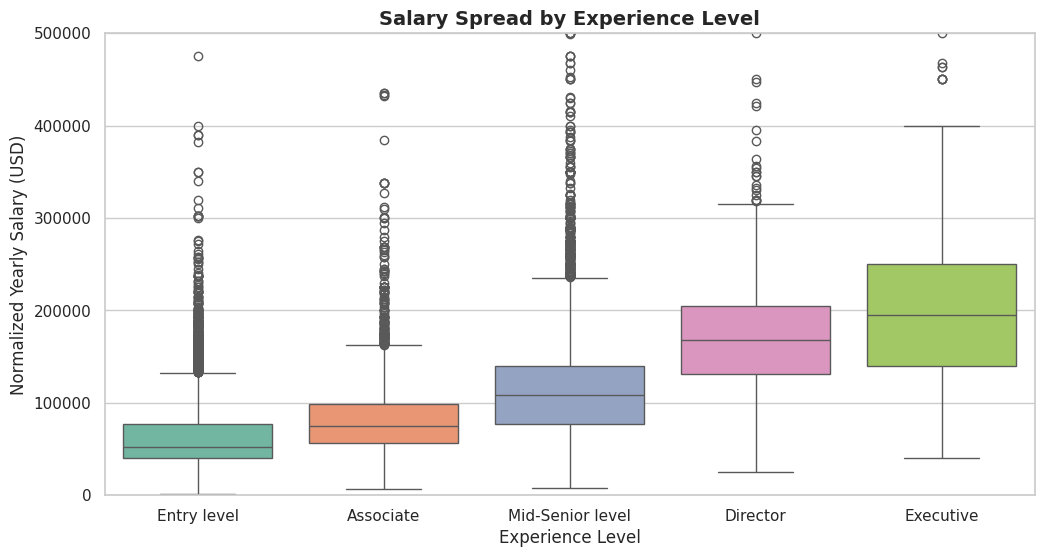

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the clean data
df_viz = pd.read_csv('linkedin_data_roles_raw_nulls.csv')

df_sal = df_viz.dropna(subset=['normalized_salary'])

sns.set_theme(style="whitegrid")


plt.figure(figsize=(12, 6))

exp_order = ['Entry level', 'Associate', 'Mid-Senior level', 'Director', 'Executive']
sns.boxplot(data=df_sal, x='formatted_experience_level', y='normalized_salary', order=exp_order, palette='Set2')
plt.title('Salary Spread by Experience Level', fontsize=14, fontweight='bold')
plt.xlabel('Experience Level', fontsize=12)
plt.ylabel('Normalized Yearly Salary (USD)', fontsize=12)
plt.ylim(0, 500000)
plt.show()



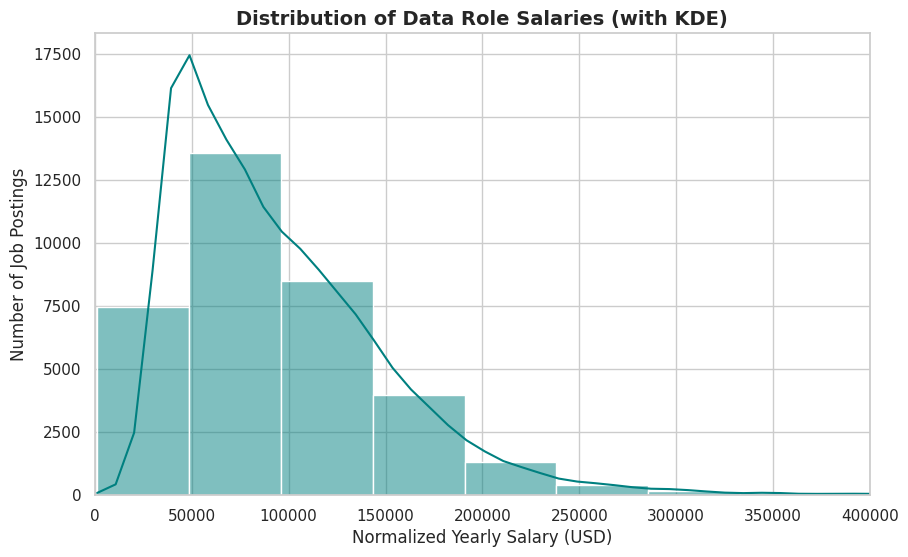

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_sal, x='normalized_salary', kde=True, bins=40, color='teal')
plt.title('Distribution of Data Role Salaries (with KDE)', fontsize=14, fontweight='bold')
plt.xlabel('Normalized Yearly Salary (USD)', fontsize=12)
plt.ylabel('Number of Job Postings', fontsize=12)
plt.xlim(0, 400000)
plt.show()

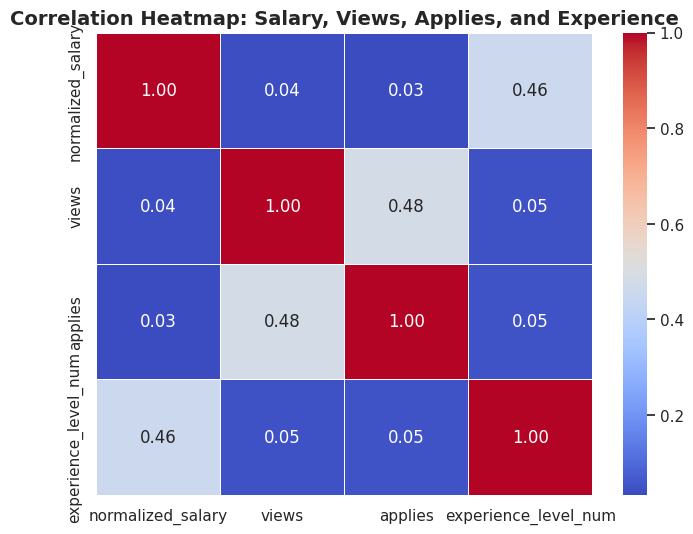

In [ ]:
plt.figure(figsize=(8, 6))
if 'experience_level_num' not in df_viz.columns:
    exp_map = {
        'internship': 0,
        'entry level': 1,
        'associate': 2,
        'mid-senior level': 3,
        'director': 4,
        'executive': 5
    }
    df_viz['experience_level_num'] = df_viz['formatted_experience_level'].str.lower().map(exp_map)

num_cols = df_viz[['normalized_salary', 'views', 'applies', 'experience_level_num']]
corr_matrix = num_cols.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Salary, Views, Applies, and Experience', fontsize=14, fontweight='bold')
plt.show()

/tmp/ipykernel_2390/4096201206.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_titles.values, y=top_titles.index, palette='viridis')


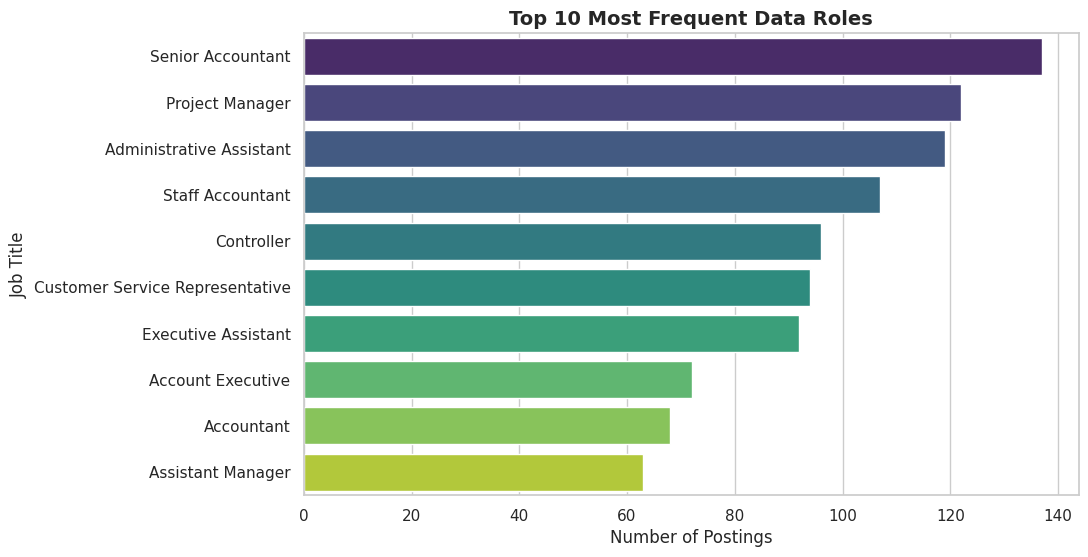

In [ ]:
plt.figure(figsize=(10, 6))
top_titles = df_viz['title'].value_counts().head(10)
sns.barplot(x=top_titles.values, y=top_titles.index, palette='viridis')
plt.title('Top 10 Most Frequent Data Roles', fontsize=14, fontweight='bold')
plt.xlabel('Number of Postings', fontsize=12)
plt.ylabel('Job Title', fontsize=12)
plt.show()

In [ ]:
if 'industry' in df_viz.columns:
    plt.figure(figsize=(10, 6))
    top_ind = df_viz['industry'].value_counts().head(10)
    sns.barplot(x=top_ind.values, y=top_ind.index, palette='magma')
    plt.title('Top 10 Industries Hiring Data Roles', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Postings', fontsize=12)
    plt.ylabel('Industry', fontsize=12)
    plt.show() #Modify it

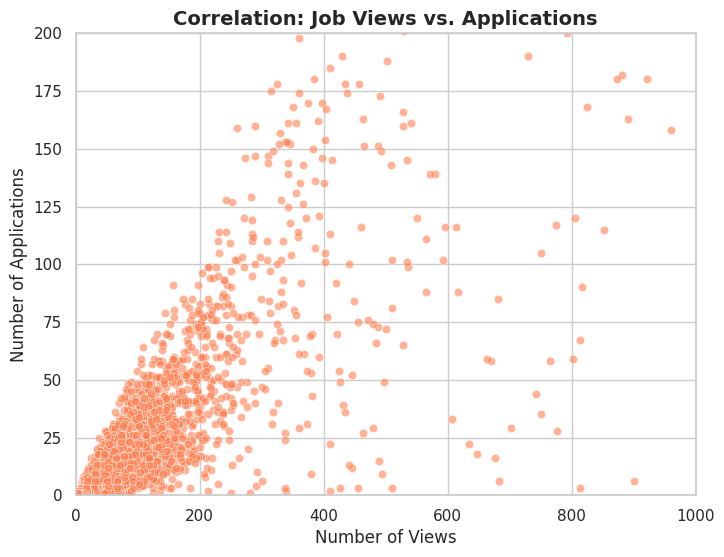

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_viz, x='views', y='applies', alpha=0.6, color='coral')
plt.title('Correlation: Job Views vs. Applications', fontsize=14, fontweight='bold')
plt.xlabel('Number of Views', fontsize=12)
plt.ylabel('Number of Applications', fontsize=12)

plt.xlim(0, 1000)
plt.ylim(0, 200)
plt.show()